# Training a Machine Model to predict Placement Status of a Student according to Academic records

In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("data/student_career_success_dataset.csv")
df.head()

,Student_ID,Age,Gender,University_Year,Major,Attendance_Percentage,Study_Hours_Per_Week,CGPA,Academic_Performance,Programming_Skill,...,Teamwork,Problem_Solving,English_Proficiency,Interview_Score,Employability_Score,Placement_Status,Company_Tier,Career_Field,Placement_Mode,Starting_Salary_USD
0,ST000001,22,Male,Sophomore,Computer Science,86,21,3.28,Good,9,...,7,8,Advanced,72,231.70,Placed,Tier 1,Backend Developer,Campus Placement,72082
1,ST000002,20,Female,Freshman,Computer Science,64,18,2.53,Poor,6,...,6,5,Basic,59,157.45,Not Placed,No Company,Not Placed,Not Applicable,0
2,ST000003,23,Male,Senior,Information Technology,75,19,2.83,Average,8,...,8,7,Advanced,76,203.45,Placed,Tier 1,IT Support Engineer,Campus Placement,94898
3,ST000004,23,Female,Senior,Information Technology,80,19,2.80,Average,5,...,6,6,Intermediate,67,171.50,Not Placed,No Company,Not Placed,Not Applicable,0
4,ST000005,23,Female,Senior,Software Engineering,73,19,2.93,Average,9,...,8,9,Advanced,82,225.45,Placed,Tier 1,Software Engineer,Internship Conversion,85256


In [3]:
df.columns

Index(['Student_ID', 'Age', 'Gender', 'University_Year', 'Major',
       'Attendance_Percentage', 'Study_Hours_Per_Week', 'CGPA',
       'Academic_Performance', 'Programming_Skill', 'Projects_Completed',
       'Certifications', 'Hackathons', 'GitHub_Profile', 'Internships',
       'Leadership_Experience', 'LinkedIn_Profile', 'Resume_Score',
       'Communication_Skills', 'Teamwork', 'Problem_Solving',
       'English_Proficiency', 'Interview_Score', 'Employability_Score',
       'Placement_Status', 'Company_Tier', 'Career_Field', 'Placement_Mode',
       'Starting_Salary_USD'],
      dtype='str')

In [4]:
X = df.drop(columns=['Student_ID','Placement_Status', 'Company_Tier', 'Career_Field', 'Placement_Mode','Starting_Salary_USD'])
y = df["Placement_Status"].map({"Placed":1,"Not Placed":0})

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,y,test_size=0.2,random_state=42,stratify=y
)

In [6]:
from sklearn.metrics import precision_score, accuracy_score, recall_score, f1_score, classification_report, confusion_matrix

def evaluate_model(model):

    y_pred = model.predict(X_test)

    precision = round(precision_score(y_test, y_pred)*100,3)
    accuracy = round(accuracy_score(y_test, y_pred)*100,3)
    recall = round(recall_score(y_test, y_pred)*100,3)
    f1 = round(f1_score(y_test, y_pred)*100,3)

   

    print("Model Evaluation:")
    print(f"Precision Score : {precision} %")
    print(f"Accuracy Score : {accuracy} %")
    print(f"Recall Score : {recall} %")
    print(f"F1 Score : {f1} %")

    print(f"Classification Report:\n{classification_report(y_test, y_pred)}")
    print(f"Confusion Matrix:\n{confusion_matrix(y_test, y_pred)}")


def get_metrics(model):

    y_pred = model.predict(X_test)

    return {
        "Accuracy": accuracy_score(y_test, y_pred) * 100,
        "Precision": precision_score(y_test, y_pred) * 100,
        "Recall": recall_score(y_test, y_pred) * 100,
        "F1": f1_score(y_test, y_pred) * 100,
        "Macro F1": f1_score(y_test, y_pred, average="macro") * 100
    }

In [7]:
cat_cols = X.select_dtypes(include="str").columns
num_cols = X.select_dtypes(exclude="str").columns

In [8]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
scaler = StandardScaler()
ohe = OneHotEncoder()

In [9]:
from sklearn.compose import ColumnTransformer
preprocess = ColumnTransformer(
    transformers=[
        ("num",scaler,num_cols),
        ("cat",ohe,cat_cols)
    ]
)

In [10]:
from sklearn.pipeline import Pipeline
def into_pipe(model):
    pipe=Pipeline(
        steps=[
            ("preprocess",preprocess),
            ("model",model)
        ]
    )
    return pipe

In [11]:
results = {}

In [12]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression(max_iter=1000)
lr_pipe=into_pipe(lr)
lr_pipe.fit(X_train,y_train)
evaluate_model(lr_pipe)
results["Logistic Regression"] = get_metrics(lr_pipe)

Model Evaluation:
Precision Score : 84.179 %
Accuracy Score : 81.89 %
Recall Score : 94.582 %
F1 Score : 89.078 %
Classification Report:
              precision    recall  f1-score   support

           0       0.66      0.37      0.47      2192
           1       0.84      0.95      0.89      7808

    accuracy                           0.82     10000
   macro avg       0.75      0.66      0.68     10000
weighted avg       0.80      0.82      0.80     10000

Confusion Matrix:
[[ 804 1388]
 [ 423 7385]]


### Logistic Regression — Results

Logistic Regression achieved an accuracy of 81.89% and an F1-score of 89.08% for the Placed class.

The model performs substantially better on the Placed class than on the Not Placed class. For Placed students, the model achieves 94.58% recall, correctly identifying most students who were actually placed.

However, the recall for Not Placed students is only 37%. Out of 2,192 students who were actually not placed, the model correctly identified 804 and incorrectly classified 1,388 as placed.

This indicates that the model has difficulty identifying the minority Not Placed class and tends to predict Placed more frequently.

In [13]:
from sklearn.naive_bayes import GaussianNB
gnb = GaussianNB()
gnb_pipe = into_pipe(gnb)
gnb_pipe.fit(X_train,y_train)
evaluate_model(gnb_pipe)
results["Gaussian Naive-Bayes"] = get_metrics(gnb_pipe)

Model Evaluation:
Precision Score : 88.005 %
Accuracy Score : 76.67 %
Recall Score : 81.186 %
F1 Score : 84.458 %
Classification Report:
              precision    recall  f1-score   support

           0       0.47      0.61      0.53      2192
           1       0.88      0.81      0.84      7808

    accuracy                           0.77     10000
   macro avg       0.68      0.71      0.69     10000
weighted avg       0.79      0.77      0.78     10000

Confusion Matrix:
[[1328  864]
 [1469 6339]]


### Naive Bayes — Results

Naive Bayes achieved an accuracy of 76.67% and an F1-score of 84.46% for the Placed class.

Compared with Logistic Regression, Naive Bayes achieved substantially higher recall for the Not Placed class (61% vs. 37%), correctly identifying more students who were actually not placed. However, its precision for this class was lower (47%), resulting in a larger number of students being incorrectly classified as Not Placed.

Overall, Naive Bayes produced lower accuracy and Placed-class performance than Logistic Regression, but it showed a different behavior in handling the minority Not Placed class.

In [14]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=9)
knn_pipe = into_pipe(knn)
knn_pipe.fit(X_train,y_train)
evaluate_model(knn_pipe)
results["kNN"] = get_metrics(knn_pipe)

Model Evaluation:
Precision Score : 83.896 %
Accuracy Score : 80.6 %
Recall Score : 93.007 %
F1 Score : 88.217 %
Classification Report:
              precision    recall  f1-score   support

           0       0.59      0.36      0.45      2192
           1       0.84      0.93      0.88      7808

    accuracy                           0.81     10000
   macro avg       0.72      0.65      0.67     10000
weighted avg       0.79      0.81      0.79     10000

Confusion Matrix:
[[ 798 1394]
 [ 546 7262]]


In [15]:
from sklearn.model_selection import GridSearchCV
params = {
    "model__n_neighbors":[3,5,7,9,11]
}
grid = GridSearchCV(
    estimator=knn_pipe,
    param_grid=params,
    cv=5,
    scoring="f1_macro"
)
grid.fit(X_train,y_train)
print("Best parameters : ", grid.best_params_)

Best parameters :  {'model__n_neighbors': 9}


### KNN — Results

K-Nearest Neighbors (KNN) was evaluated as a baseline model after applying the preprocessing pipeline. Since KNN relies on distances between observations, numerical features were standardized before calculating distances.

The baseline KNN model achieved an accuracy of 80.60% and an F1-score of 88.22% for the Placed class. The model performed substantially better on the Placed class than on the Not Placed class. The recall for Not Placed was only 36%, meaning that most students who were actually not placed were incorrectly classified as placed.

The model's behavior is similar to Logistic Regression, with strong performance on the majority Placed class but limited ability to identify the minority Not Placed class.

#### Hyperparameter Tuning

To investigate whether KNN's performance could be improved, GridSearchCV was used to search over different values of n_neighbors, distance weighting, and distance metrics. Macro F1-score was used as the optimization metric so that both classes contributed equally despite the class imbalance. The best configuration found was: n_neighbors = 9

In [16]:
from sklearn.ensemble import RandomForestClassifier
rfc = RandomForestClassifier(
    n_estimators=201,
    max_depth=None,
    min_samples_leaf=2,
    min_samples_split=5,
    oob_score=True,
    random_state=42
)
rfc_pipe = into_pipe(rfc)
rfc_pipe.fit(X_train,y_train)
evaluate_model(rfc_pipe)
results["Random Forest Classifier"] = get_metrics(rfc_pipe)
print("OOB Score : ",rfc.oob_score_)

Model Evaluation:
Precision Score : 84.223 %
Accuracy Score : 81.83 %
Recall Score : 94.416 %
F1 Score : 89.028 %
Classification Report:
              precision    recall  f1-score   support

           0       0.65      0.37      0.47      2192
           1       0.84      0.94      0.89      7808

    accuracy                           0.82     10000
   macro avg       0.75      0.66      0.68     10000
weighted avg       0.80      0.82      0.80     10000

Confusion Matrix:
[[ 811 1381]
 [ 436 7372]]
OOB Score :  0.815975


### Random Forest — Results

Random Forest achieved an accuracy of 81.82%, with an F1-score of 89.01% for the Placed class. Similar to Logistic Regression and KNN, it performed substantially better on the Placed class than on the Not Placed class. The recall for Not Placed was 37%, with 821 out of 2,192 actually not-placed students correctly identified. The model achieved an OOB score of 81.59%, which was close to its test accuracy of 81.82%. Overall, Random Forest showed performance similar to the Logistic Regression baseline, without substantially improving identification of the minority class.

In [17]:
from xgboost import XGBClassifier
xgb = XGBClassifier(
    n_estimators = 201,
    learning_rate = 0.1,
    random_state = 42
)
xgb_pipe = into_pipe(xgb)
xgb_pipe.fit(X_train,y_train)
evaluate_model(xgb_pipe)
results["XGBoost"] = get_metrics(xgb_pipe)


Model Evaluation:
Precision Score : 84.279 %
Accuracy Score : 81.84 %
Recall Score : 94.339 %
F1 Score : 89.026 %
Classification Report:
              precision    recall  f1-score   support

           0       0.65      0.37      0.47      2192
           1       0.84      0.94      0.89      7808

    accuracy                           0.82     10000
   macro avg       0.75      0.66      0.68     10000
weighted avg       0.80      0.82      0.80     10000

Confusion Matrix:
[[ 818 1374]
 [ 442 7366]]


### XGBoost - Result

XGBoost achieved an accuracy of 81.84% and an F1-score of 89.03% for the Placed class. Its performance was very similar to Random Forest, with a Not Placed recall of 37% and a Placed recall of 94%. Thus, despite its boosting-based ensemble approach, XGBoost did not substantially improve identification of the minority Not Placed class on this dataset

In [18]:
from sklearn.ensemble import VotingClassifier
vote = VotingClassifier(
    estimators=[
        ("lr",lr),
        ("gnb",gnb),
        ("rfc",rfc)
    ]
)
vote_pipe = into_pipe(vote)
vote_pipe.fit(X_train,y_train)
evaluate_model(vote_pipe)
results["Voting"] = get_metrics(vote_pipe)

Model Evaluation:
Precision Score : 84.444 %
Accuracy Score : 81.88 %
Recall Score : 94.134 %
F1 Score : 89.026 %
Classification Report:
              precision    recall  f1-score   support

           0       0.65      0.38      0.48      2192
           1       0.84      0.94      0.89      7808

    accuracy                           0.82     10000
   macro avg       0.75      0.66      0.69     10000
weighted avg       0.80      0.82      0.80     10000

Confusion Matrix:
[[ 838 1354]
 [ 458 7350]]


### Voting - Result

The Voting Classifier achieved an accuracy of 81.88% and a macro F1-score of 0.69. Its performance was broadly similar to the individual models, with a slight improvement in the recall and F1-score of the Not Placed class. This suggests that combining the selected models did not produce a substantial performance improvement, as several of the component models exhibited similar prediction behavior

In [19]:
final_eval=pd.DataFrame(results)
final_eval

,Logistic Regression,Gaussian Naive-Bayes,kNN,Random Forest Classifier,XGBoost,Voting
Accuracy,81.890000,76.670000,80.600000,81.830000,81.840000,81.880000
Precision,84.178730,88.004998,83.895564,84.222552,84.279176,84.443934
Recall,94.582480,81.185963,93.007172,94.415984,94.339139,94.134221
F1,89.077860,84.458064,88.216715,89.028440,89.025864,89.026163
Macro F1,68.054578,68.847593,66.676231,68.096657,68.209340,68.538311


In [20]:
# For Minority(Not Placed) class comparision

def get_class_metrics(model, class_label=0):

    y_pred = model.predict(X_test)

    report = classification_report(
        y_test,
        y_pred,
        output_dict=True
    )

    return {
        "Precision": report[str(class_label)]["precision"] * 100,
        "Recall": report[str(class_label)]["recall"] * 100,
        "F1": report[str(class_label)]["f1-score"] * 100
    }

minority_results = {}

minority_results["Logistic Regression"] = get_class_metrics(lr_pipe)
minority_results["Gaussian Naive-Bayes"] = get_class_metrics(gnb_pipe)
minority_results["kNN"] = get_class_metrics(knn_pipe)
minority_results["Random Forest Classifier"] = get_class_metrics(rfc_pipe)
minority_results["XGBoost"] = get_class_metrics(xgb_pipe)
minority_results["Voting"] = get_class_metrics(vote_pipe)

minority_df = pd.DataFrame(minority_results).T

minority_df

,Precision,Recall,F1
Logistic Regression,65.525672,36.678832,47.031296
Gaussian Naive-Bayes,47.479442,60.583942,53.237122
kNN,59.375000,36.405109,45.135747
Random Forest Classifier,65.036087,36.998175,47.164874
XGBoost,64.920635,37.317518,47.392816
Voting,64.660494,38.229927,48.050459


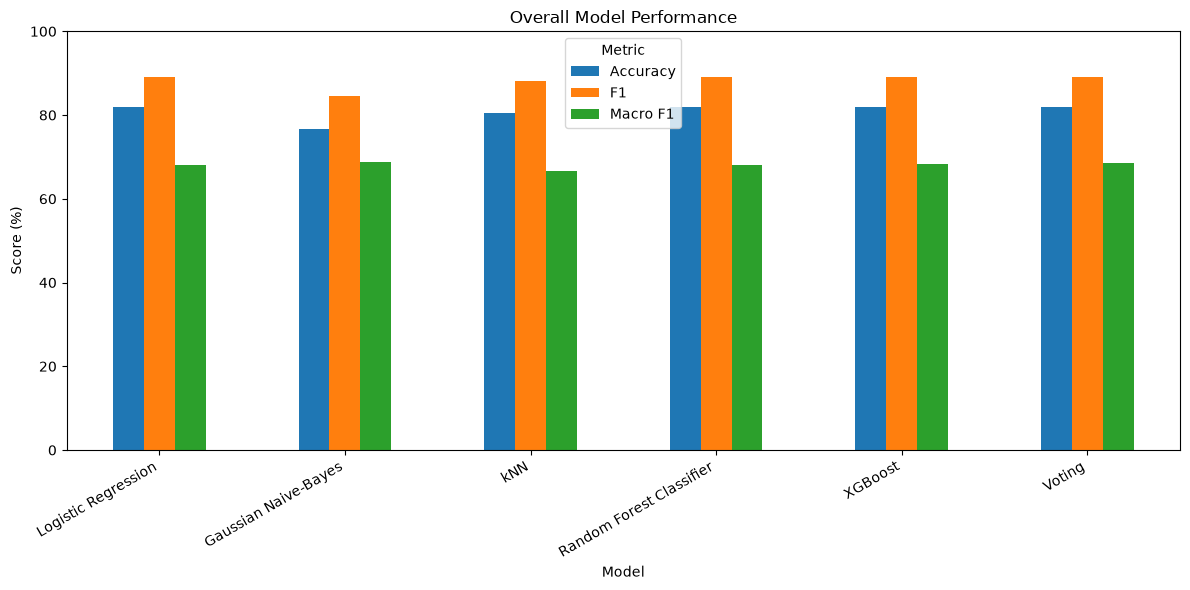

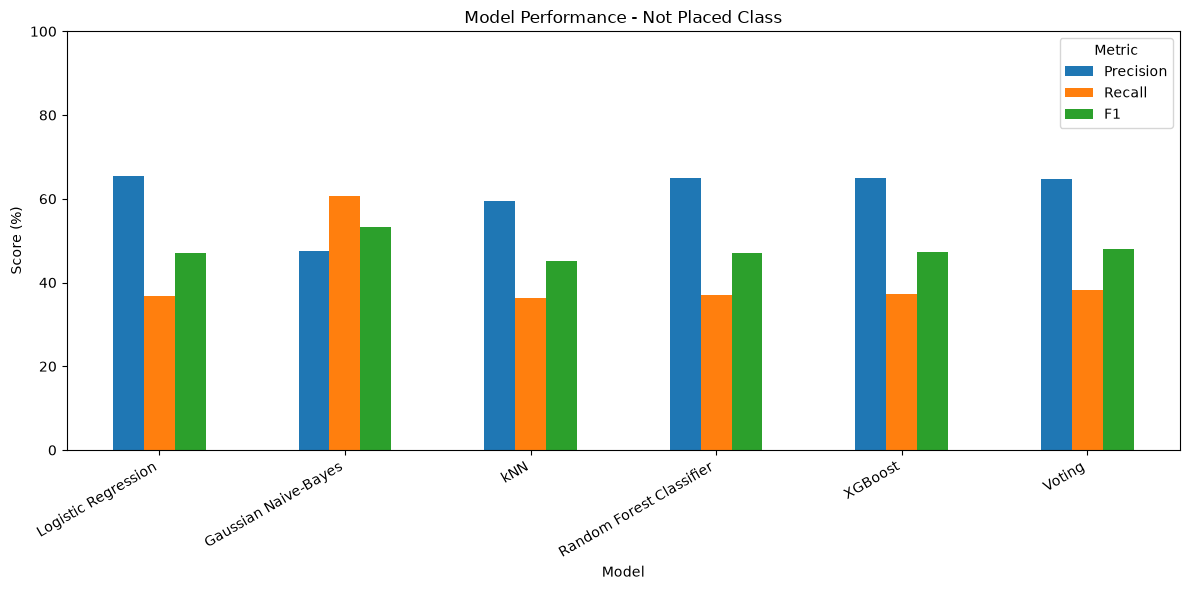

In [21]:
import matplotlib.pyplot as plt

# -------------------------------
# 1. Overall Model Performance
# -------------------------------
results_df = pd.DataFrame(results).T
overall_metrics = results_df[
    ["Accuracy", "F1", "Macro F1"]
]

overall_metrics.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Overall Model Performance")
plt.xlabel("Model")
plt.ylabel("Score (%)")
plt.ylim(0, 100)
plt.xticks(rotation=30, ha="right")
plt.legend(title="Metric")
plt.tight_layout()
plt.show()


# ------------------------------------
# 2. Not Placed Class Performance
# ------------------------------------

minority_df[
    ["Precision", "Recall", "F1"]
].plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Model Performance - Not Placed Class")
plt.xlabel("Model")
plt.ylabel("Score (%)")
plt.ylim(0, 100)
plt.xticks(rotation=30, ha="right")
plt.legend(title="Metric")
plt.tight_layout()
plt.show()

## Model Comparison

The models achieved similar overall accuracy, with most models performing
around 81–82%. However, accuracy alone does not provide a complete picture
because the dataset is imbalanced, with `Placed` being the majority class.

Therefore, the performance of the `Not Placed` class was also examined
separately.

Gaussian Naive-Bayes showed noticeably different behavior from the other
models. It achieved a recall of approximately 60.6% for the `Not Placed`
class, compared with approximately 36–38% for the other models. However,
this came with a lower precision of 47.5%, indicating that the model also
classified a larger number of actually placed students as not placed.

Logistic Regression, kNN, Random Forest, and XGBoost produced very similar
minority-class recall values. The Voting Classifier provided only a modest
increase in `Not Placed` recall to approximately 38.2%, suggesting that
combining these models did not substantially change their prediction
behavior.

Overall, the results demonstrate that model performance depends on the
metric being considered. Models with similar accuracy can have substantially
different behavior across individual classes.

## Conclusion

1. This project focused on predicting whether a student would be placed based on their academic, technical, and other student-related features.
2. During EDA and preprocessing, features that could introduce data leakage were identified and removed. The dataset was also found to be imbalanced, with the `Placed` class representing the majority of observations.
3. Several classification algorithms were trained and evaluated, including Logistic Regression, Gaussian Naive-Bayes, kNN, Random Forest, XGBoost, and a Voting Classifier. Most models achieved similar overall performance, with accuracy around 81–82%.
4. However, evaluating the individual classes revealed an important difference. Most models had relatively low recall for the `Not Placed` class, while Gaussian Naive-Bayes achieved considerably higher recall for this class, at the cost of lower overall accuracy and precision.
5. The results show that accuracy alone is not sufficient for evaluating this problem. Different models make different trade-offs between the `Placed` and `Not Placed` classes, making metrics such as class-wise recall, F1-score, and Macro F1 important for understanding model behavior.
6. Overall, this project provided a complete machine learning workflow, from data analysis and preprocessing to model training, hyperparameter tuning, evaluation, and comparison.